# 🏭 Data Center - Prediksi PUE (Power Usage Effectiveness)

**Tujuan:** Membangun model Machine Learning untuk memprediksi nilai PUE pada fasilitas data center.

**Tahapan:**
1. Exploratory Data Analysis (EDA)
2. Preprocessing
3. Modeling
4. Evaluasi

---

## 📦 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agar plot tampil rapi di notebook
%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Library berhasil diimport')

✅ Library berhasil diimport


## 📂 2. Load Dataset

In [ ]:
DATA_PATH = '____DATASET___.csv'

df = pd.read_csv(DATA_PATH)

print(f'✅ Dataset berhasil dimuat')
print(f'   Jumlah baris  : {df.shape[0]:,}')
print(f'   Jumlah kolom  : {df.shape[1]}')

✅ Dataset berhasil dimuat
   Jumlah baris  : 126,770
   Jumlah kolom  : 14


## 🔍 3. Tampilan Awal Data

In [3]:
# 5 baris pertama
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [4]:
# Tipe data setiap kolom
df.dtypes

Year                               int64
Facility_ID                          str
Facility_Name                        str
Owner_Company                        str
City                                 str
Country                              str
Facility_Type                        str
Estimated_Capacity_MW            float64
PUE                              float64
Cooling_System_Type                  str
WUE_L_per_kWh                    float64
Daily_Electricity_Usage_MWh      float64
Daily_Water_Usage_Gallons        float64
Surrounding_Water_Stress_Tier        str
dtype: object

In [5]:
# Info umum dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  str    
 2   Facility_Name                  126770 non-null  str    
 3   Owner_Company                  126770 non-null  str    
 4   City                           126770 non-null  str    
 5   Country                        126770 non-null  str    
 6   Facility_Type                  126770 non-null  str    
 7   Estimated_Capacity_MW          126770 non-null  float64
 8   PUE                            126770 non-null  float64
 9   Cooling_System_Type            126770 non-null  str    
 10  WUE_L_per_kWh                  126770 non-null  float64
 11  Daily_Electricity_Usage_MWh    126770 non-null  float64
 12  Daily_Water_Usage_Gallons      126770 non

## 📊 4. Statistik Deskriptif

In [8]:
# Statistik untuk kolom numerik
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
Year,126770.000000,2022.000000,2.000008,2019.000000,2020.000000,2022.000000,2024.000000,2025.000000
Estimated_Capacity_MW,126770.000000,23.075117,45.847195,1.000000,5.450000,9.870000,14.180000,562.890000
PUE,126770.000000,1.637746,0.190833,1.057000,1.518000,1.643000,1.787000,2.000000
WUE_L_per_kWh,126770.000000,0.820596,0.925481,0.001000,0.139000,0.232000,1.654000,3.000000
Daily_Electricity_Usage_MWh,126770.000000,605.222368,1040.061940,22.190000,167.432500,302.750000,451.370000,14812.660000
Daily_Water_Usage_Gallons,126770.000000,131218.164755,397962.899982,224.010000,4840.537500,12181.295000,75730.682500,7585092.350000


## ❓ 5. Cek Missing Values

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).query('`Missing Count` > 0')

if missing_df.empty:
    print('✅ Tidak ada missing values!')
else:
    print(f'⚠️  Ditemukan missing values:')
    display(missing_df)

✅ Tidak ada missing values!


## 🔁 6. Cek Duplikasi

In [10]:
dup_count = df.duplicated().sum()

if dup_count == 0:
    print('✅ Tidak ada data duplikat!')
else:
    print(f'⚠️  Ditemukan {dup_count} baris duplikat')

✅ Tidak ada data duplikat!


## 🎯 7. Distribusi Target: PUE

/tmp/ipykernel_40318/1587537932.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['PUE'], vert=True, patch_artist=True,


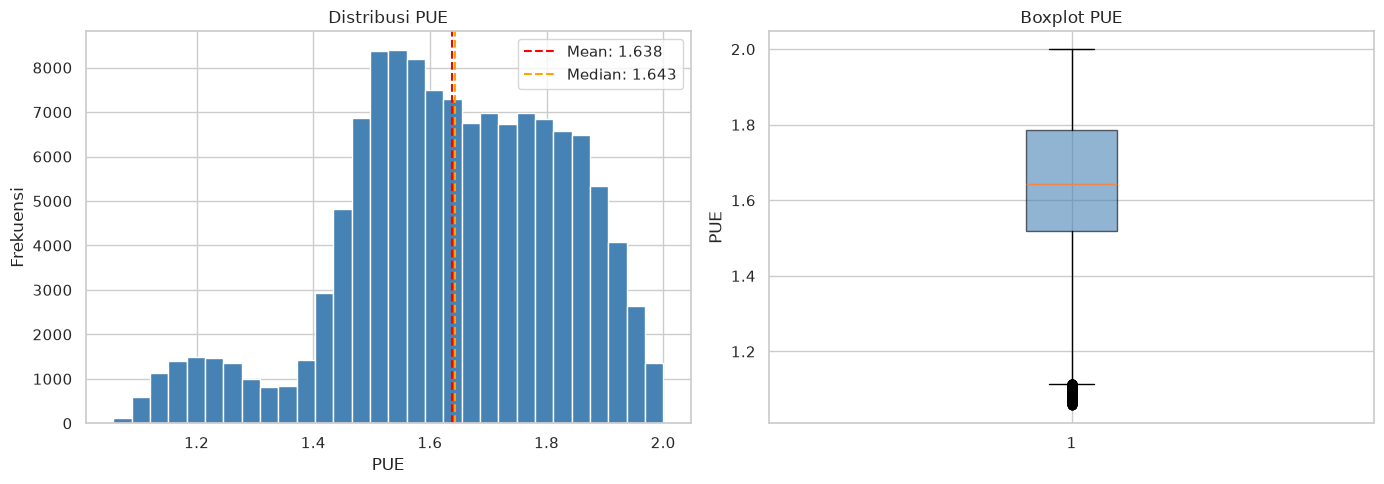

Mean   : 1.6377
Median : 1.6430
Std    : 0.1908
Min    : 1.0570
Max    : 2.0000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['PUE'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi PUE')
axes[0].set_xlabel('PUE')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['PUE'].mean(), color='red', linestyle='--', label=f'Mean: {df["PUE"].mean():.3f}')
axes[0].axvline(df['PUE'].median(), color='orange', linestyle='--', label=f'Median: {df["PUE"].median():.3f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['PUE'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot PUE')
axes[1].set_ylabel('PUE')

plt.tight_layout()
plt.show()

print(f'Mean   : {df["PUE"].mean():.4f}')
print(f'Median : {df["PUE"].median():.4f}')
print(f'Std    : {df["PUE"].std():.4f}')
print(f'Min    : {df["PUE"].min():.4f}')
print(f'Max    : {df["PUE"].max():.4f}')

## 📈 8. Distribusi Fitur Numerik

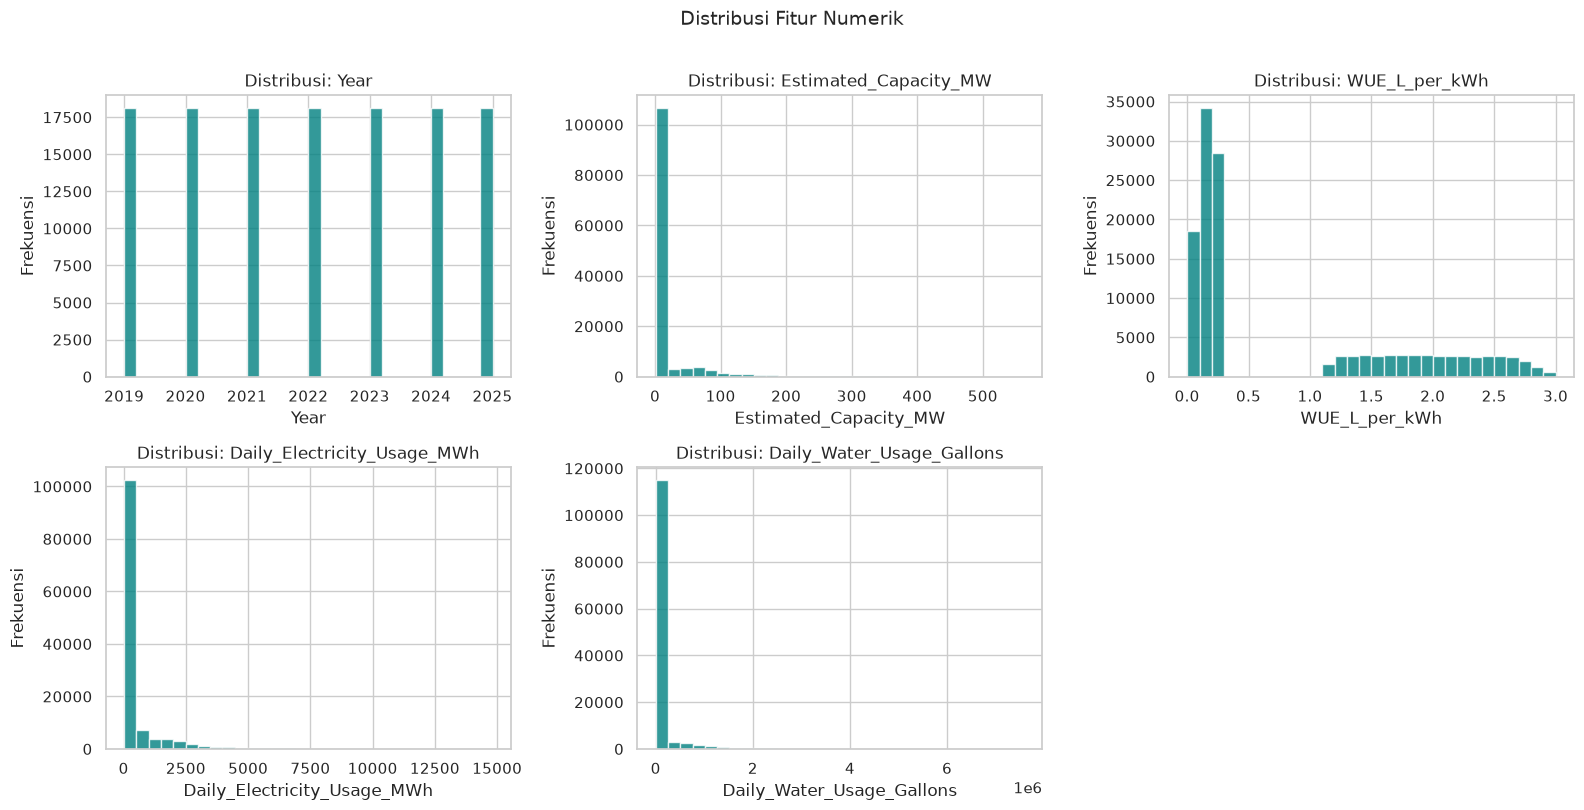

In [12]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
# Hapus target dari list untuk visualisasi terpisah
num_features = [c for c in num_cols if c != 'PUE']

n = len(num_features)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col].dropna(), bins=30, color='teal', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan axes kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 🔗 9. Korelasi Fitur dengan PUE

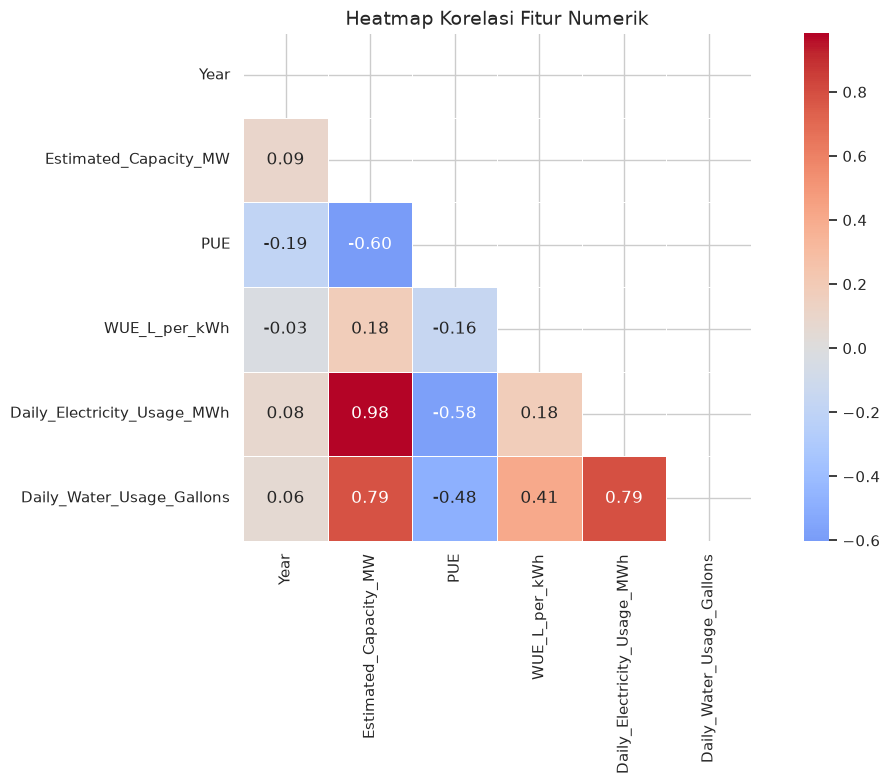

In [13]:
# Heatmap korelasi semua fitur numerik
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

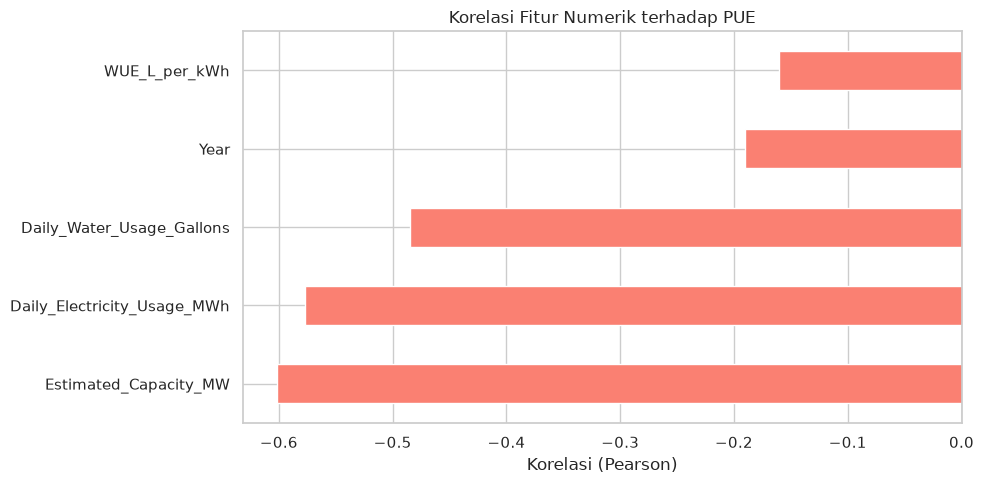


Nilai korelasi terhadap PUE:
Estimated_Capacity_MW         -0.601272
Daily_Electricity_Usage_MWh   -0.576587
Daily_Water_Usage_Gallons     -0.484959
Year                          -0.190219
WUE_L_per_kWh                 -0.160029


In [15]:
# Korelasi spesifik terhadap PUE (diurutkan)
pue_corr = corr_matrix['PUE'].drop('PUE').sort_values()

colors = ['salmon' if v < 0 else 'steelblue' for v in pue_corr]

plt.figure(figsize=(10, 5))
pue_corr.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur Numerik terhadap PUE')
plt.xlabel('Korelasi (Pearson)')
plt.tight_layout()
plt.show()

print('\nNilai korelasi terhadap PUE:')
print(pue_corr.to_string())

## 🏷️ 10. Analisa Fitur Kategorikal

In [16]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Kolom kategorikal: {cat_cols}\n')

for col in cat_cols:
    print(f'[{col}] — {df[col].nunique()} nilai unik')
    print(df[col].value_counts().head(10))
    print()

/tmp/ipykernel_40318/3845674934.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Kolom kategorikal: ['Facility_ID', 'Facility_Name', 'Owner_Company', 'City', 'Country', 'Facility_Type', 'Cooling_System_Type', 'Surrounding_Water_Stress_Tier']

[Facility_ID] — 18110 nilai unik
Facility_ID
DC-D2763E00    7
DC-97AB1D99    7
DC-F1A55D5B    7
DC-40C11C98    7
DC-179E6B7B    7
DC-F3250F8F    7
DC-5FAB2707    7
DC-1B753A37    7
DC-27AB498F    7
DC-4E79E5A8    7
Name: count, dtype: int64

[Facility_Name] — 16286 nilai unik
Facility_Name
Amsterdam    231
Singapore    217
London       189
Sydney       161
Frankfurt    154
Toronto      140
Hong Kong    133
Melbourne    126
New York     126
Chicago      119
Name: count, dtype: int64

[Owner_Company] — 4180 nilai unik
Owner_Company
Amazon AWS              3731
Equinix                 3374
Lumen                   2821
China Telecom           2212
Zenlayer                2163
Digital Realty          2093
DataBank                1519
Google                  1435
Microsoft               1316
Digital Realty Trust    1148
Name: count,

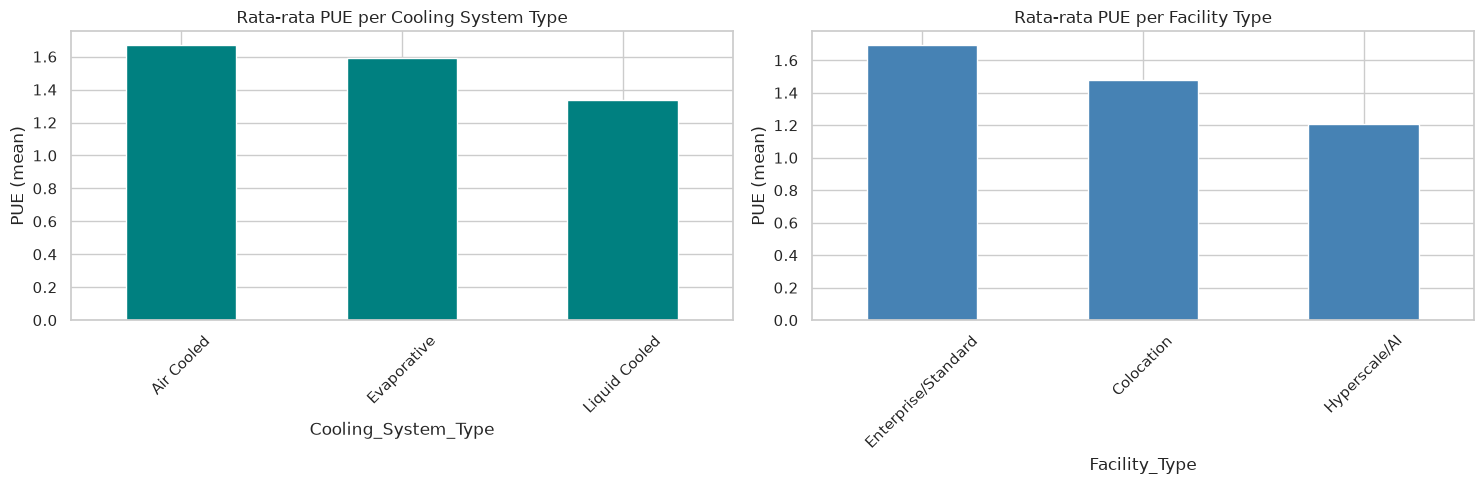

In [19]:
# PUE rata-rata per Cooling System Type
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cooling System vs PUE
cooling_pue = df.groupby('Cooling_System_Type')['PUE'].mean().sort_values(ascending=False)
cooling_pue.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Rata-rata PUE per Cooling System Type')
axes[0].set_ylabel('PUE (mean)')
axes[0].tick_params(axis='x', rotation=45)

# Facility Type vs PUE
facility_pue = df.groupby('Facility_Type')['PUE'].mean().sort_values(ascending=False)
facility_pue.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Rata-rata PUE per Facility Type')
axes[1].set_ylabel('PUE (mean)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

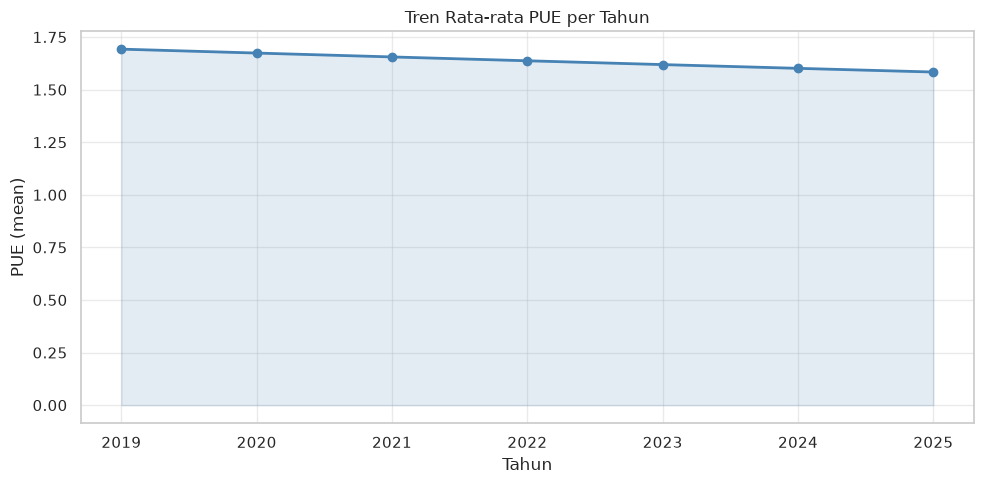

In [20]:
# Tren PUE per tahun
yearly_pue = df.groupby('Year')['PUE'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_pue.index, yearly_pue.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(yearly_pue.index, yearly_pue.values, alpha=0.15, color='steelblue')
plt.title('Tren Rata-rata PUE per Tahun')
plt.xlabel('Tahun')
plt.ylabel('PUE (mean)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 📝 11. Ringkasan EDA

> Isi bagian ini setelah menjalankan semua cell di atas berdasarkan output yang kamu dapat.

Hal-hal yang perlu dicatat:
- Distribusi PUE: apakah normal atau skewed?
jawban : jujur saya belum paham membedakannya
- Fitur mana yang paling berkorelasi dengan PUE?
-- 1. Fitur yang memiliki korelasi negatif, dimana saling bertolak belakang impactnya
Estimated_Capacity_MW         -0.601272
Daily_Electricity_Usage_MWh   -0.576587
Daily_Water_Usage_Gallons     -0.484959
-- 2.tipe pendingin air cooled berpengaruh dan juga tipe enterpriseStandart juga 
- Apakah ada missing values atau duplikat?
--tidak ada
- Pola menarik apa yang ditemukan dari visualisasi?
menurut saya fitur dari  yang saya sebutkan di point nomor 2 dapat membuat pola yang sangat jelas untuk di lakukan analisis dan dapat membuat prediksi akurat mengingat nilai korelai yang cukup tinggi -60 dan jenis kategorikalnya juga


---
**Next Step → Preprocessing & Feature Engineering**

---
# 🔧 PREPROCESSING & FEATURE ENGINEERING

## 12. Pilih Fitur Relevan

Kita buang kolom yang tidak berguna untuk model:
- `Facility_ID`, `Facility_Name`, `Owner_Company`, `City`, `Country` → identitas, bukan fitur prediktif

Fitur yang kita pakai:
- **Numerik**: `Year`, `Estimated_Capacity_MW`, `WUE_L_per_kWh`, `Daily_Electricity_Usage_MWh`, `Daily_Water_Usage_Gallons`
- **Kategorikal**: `Facility_Type`, `Cooling_System_Type`, `Surrounding_Water_Stress_Tier`

In [ ]:
# Kolom yang dibuang (identitas, tidak prediktif)
DROP_COLS = ['Facility_ID', 'Facility_Name', 'Owner_Company', 'City', 'Country']

# Fitur dan target
TARGET = 'PUE'
NUMERIC_FEATURES = ['Year', 'Estimated_Capacity_MW', 'WUE_L_per_kWh',
                    'Daily_Electricity_Usage_MWh', 'Daily_Water_Usage_Gallons']
CATEGORICAL_FEATURES = ['Facility_Type', 'Cooling_System_Type', 'Surrounding_Water_Stress_Tier']

df_model = df.drop(columns=DROP_COLS).copy()

print(f'Kolom tersisa : {df_model.columns.tolist()}')
print(f'Shape         : {df_model.shape}')

## 13. Cek Distribusi PUE (Skewness)

**Skewness** mengukur seberapa miring distribusi data:
- Nilai mendekati **0** → distribusi normal (simetris)
- Nilai **negatif** → ekor di kiri (left-skewed), artinya lebih banyak data di nilai tinggi
- Nilai **positif** → ekor di kanan (right-skewed), artinya lebih banyak data di nilai rendah

Aturan praktis: jika |skewness| < 0.5 → masih bisa dianggap cukup normal.

In [ ]:
from scipy import stats

skewness = df_model[TARGET].skew()
print(f'Skewness PUE : {skewness:.4f}')

if abs(skewness) < 0.5:
    print('✅ Distribusi cukup normal, tidak perlu transformasi.')
elif skewness < 0:
    print('⚠️  Left-skewed (ekor di kiri). Distribusi lebih berat di nilai PUE tinggi.')
else:
    print('⚠️  Right-skewed (ekor di kanan). Distribusi lebih berat di nilai PUE rendah.')

## 14. Encode Fitur Kategorikal

Model ML tidak bisa memproses teks. Kita konversi kategorikal ke angka.

- `Surrounding_Water_Stress_Tier` → **Ordinal Encoding** (Low=0, Medium=1, High=2) karena ada urutan
- `Facility_Type` & `Cooling_System_Type` → **One-Hot Encoding** karena tidak ada urutan

In [ ]:
# Ordinal Encoding untuk Water Stress Tier (ada urutan: Low < Medium < High)
water_stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_model['Water_Stress_Encoded'] = df_model['Surrounding_Water_Stress_Tier'].map(water_stress_map)

# One-Hot Encoding untuk Facility_Type dan Cooling_System_Type
df_model = pd.get_dummies(
    df_model,
    columns=['Facility_Type', 'Cooling_System_Type'],
    drop_first=True  # hindari multicollinearity
)

# Buang kolom original Surrounding_Water_Stress_Tier
df_model = df_model.drop(columns=['Surrounding_Water_Stress_Tier'])

print('✅ Encoding selesai')
print(f'Kolom setelah encoding: {df_model.columns.tolist()}')
df_model.head(3)

## 15. Split Data: Train & Test

Kita bagi data menjadi:
- **80% Train** → untuk melatih model
- **20% Test** → untuk evaluasi model yang tidak pernah dilihat model sebelumnya

`random_state=42` memastikan hasil reproducible (sama setiap dijalankan).

In [ ]:
from sklearn.model_selection import train_test_split

# Pisahkan fitur (X) dan target (y)
feature_cols = [c for c in df_model.columns if c != TARGET]
X = df_model[feature_cols]
y = df_model[TARGET]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'✅ Data berhasil di-split')
print(f'   Train : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'   Fitur : {X_train.shape[1]}')

## 16. Scaling Fitur Numerik

Fitur numerik punya skala yang sangat berbeda (contoh: `Daily_Water_Usage_Gallons` bisa ratusan ribu, sementara `WUE` hanya 0–3).

Kita pakai **StandardScaler** agar semua fitur berada di skala yang sama (mean=0, std=1).

> ⚠️ Penting: Scaler di-fit HANYA pada data train, lalu di-transform ke train & test. Ini mencegah **data leakage**.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Kolom yang perlu di-scale (hanya numerik, bukan hasil one-hot)
scale_cols = NUMERIC_FEATURES + ['Water_Stress_Encoded']

scaler = StandardScaler()

# Fit pada train, transform pada train dan test
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print('✅ Scaling selesai')
print('Statistik X_train setelah scaling:')
X_train[scale_cols].describe().T[['mean', 'std']].round(4)

## 📝 Ringkasan Preprocessing

| Langkah | Detail |
|---|---|
| Fitur dibuang | Facility_ID, Facility_Name, Owner_Company, City, Country |
| Ordinal Encoding | Surrounding_Water_Stress_Tier (Low=0, Med=1, High=2) |
| One-Hot Encoding | Facility_Type, Cooling_System_Type |
| Split | 80% train / 20% test |
| Scaling | StandardScaler pada fitur numerik |

---
**Next Step → Modeling**

---
# 🤖 MODELING

Pada tahap ini kita akan:
1. Membuat baseline model (Linear Regression)
2. Mencoba model yang lebih kompleks (Random Forest, Gradient Boosting)
3. Hyperparameter tuning untuk model terbaik
4. Evaluasi dan bandingkan performa

---

## 🔧 17. Import Library untuk Modeling

In [27]:
# Algoritma ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# Evaluasi
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cross-validation
from sklearn.model_selection import cross_val_score

import time
import warnings
warnings.filterwarnings('ignore')

print('✅ Library modeling berhasil diimport')

✅ Library modeling berhasil diimport


## 📊 18. Helper Function untuk Evaluasi Model

In [28]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name='Model'):
    """
    Function untuk evaluasi model dengan berbagai metrik.
    
    Parameters:
    -----------
    model : sklearn model
        Model yang sudah di-fit
    X_train, y_train : DataFrame, Series
        Data training
    X_test, y_test : DataFrame, Series
        Data testing
    model_name : str
        Nama model untuk display
        
    Returns:
    --------
    dict : Dictionary berisi hasil evaluasi
    """
    # Prediksi
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Hitung metrik
    results = {
        'Model': model_name,
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred)
    }
    
    return results

print('✅ Helper function siap digunakan')

✅ Helper function siap digunakan


## 🎯 19. Baseline Model: Linear Regression

Kita mulai dengan model sederhana sebagai **baseline** untuk mengukur performa model lain.

In [29]:
# Training Linear Regression
print('🔄 Training Linear Regression...')
start_time = time.time()

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f'✅ Training selesai dalam {train_time:.2f} detik\n')

# Evaluasi
lr_results = evaluate_model(lr_model, X_train, y_train, X_test, y_test, 'Linear Regression')

# Display hasil
print('📊 Hasil Evaluasi Linear Regression:')
for key, value in lr_results.items():
    if key != 'Model':
        print(f'   {key:15s}: {value:.4f}')

🔄 Training Linear Regression...
✅ Training selesai dalam 0.11 detik

📊 Hasil Evaluasi Linear Regression:
   Train MAE      : 0.1253
   Test MAE       : 0.1253
   Train RMSE     : 0.1491
   Test RMSE      : 0.1490
   Train R²       : 0.3898
   Test R²        : 0.3889


## 🌲 20. Random Forest Regressor

Random Forest adalah ensemble method yang lebih powerful dari Linear Regression.

In [30]:
# Training Random Forest
print('🔄 Training Random Forest...')
start_time = time.time()

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1  # Gunakan semua core CPU
)
rf_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f'✅ Training selesai dalam {train_time:.2f} detik\n')

# Evaluasi
rf_results = evaluate_model(rf_model, X_train, y_train, X_test, y_test, 'Random Forest')

# Display hasil
print('📊 Hasil Evaluasi Random Forest:')
for key, value in rf_results.items():
    if key != 'Model':
        print(f'   {key:15s}: {value:.4f}')

🔄 Training Random Forest...
✅ Training selesai dalam 27.45 detik

📊 Hasil Evaluasi Random Forest:
   Train MAE      : 0.0449
   Test MAE       : 0.0674
   Train RMSE     : 0.0601
   Test RMSE      : 0.0840
   Train R²       : 0.9009
   Test R²        : 0.8057


## 🚀 21. Gradient Boosting Regressor

Gradient Boosting adalah algoritma yang sangat powerful untuk regression.

In [32]:
# Training Gradient Boosting
print('🔄 Training Gradient Boosting...')
start_time = time.time()

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f'✅ Training selesai dalam {train_time:.2f} detik\n')

# Evaluasi
gb_results = evaluate_model(gb_model, X_train, y_train, X_test, y_test, 'Gradient Boosting')

# Display hasil
print('📊 Hasil Evaluasi Gradient Boosting:')
for key, value in gb_results.items():
    if key != 'Model':
        print(f'   {key:15s}: {value:.4f}')

🔄 Training Gradient Boosting...
✅ Training selesai dalam 32.21 detik

📊 Hasil Evaluasi Gradient Boosting:
   Train MAE      : 0.0800
   Test MAE       : 0.0822
   Train RMSE     : 0.0970
   Test RMSE      : 0.0994
   Train R²       : 0.7418
   Test R²        : 0.7278


## 📈 22. Perbandingan Semua Model

In [33]:
# Gabungkan semua hasil
comparison_df = pd.DataFrame([lr_results, rf_results, gb_results])

# Tampilkan tabel perbandingan dengan styling
print('\n📊 PERBANDINGAN MODEL:\n')
display(comparison_df.style.background_gradient(cmap='RdYlGn_r', subset=['Test MAE', 'Test RMSE'])
                           .background_gradient(cmap='RdYlGn', subset=['Test R²'])
                           .format(precision=4))

# Model terbaik berdasarkan Test R²
best_model_name = comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']
best_r2 = comparison_df['Test R²'].max()

print(f'\n🏆 Model Terbaik: {best_model_name} (R² = {best_r2:.4f})')


📊 PERBANDINGAN MODEL:



,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Linear Regression,0.1253,0.1253,0.1491,0.1490,0.3898,0.3889
1,Random Forest,0.0449,0.0674,0.0601,0.0840,0.9009,0.8057
2,Gradient Boosting,0.0800,0.0822,0.0970,0.0994,0.7418,0.7278



🏆 Model Terbaik: Random Forest (R² = 0.8057)


## 🔍 23. Feature Importance (Random Forest)

Mari kita lihat fitur mana yang paling berpengaruh terhadap prediksi PUE.

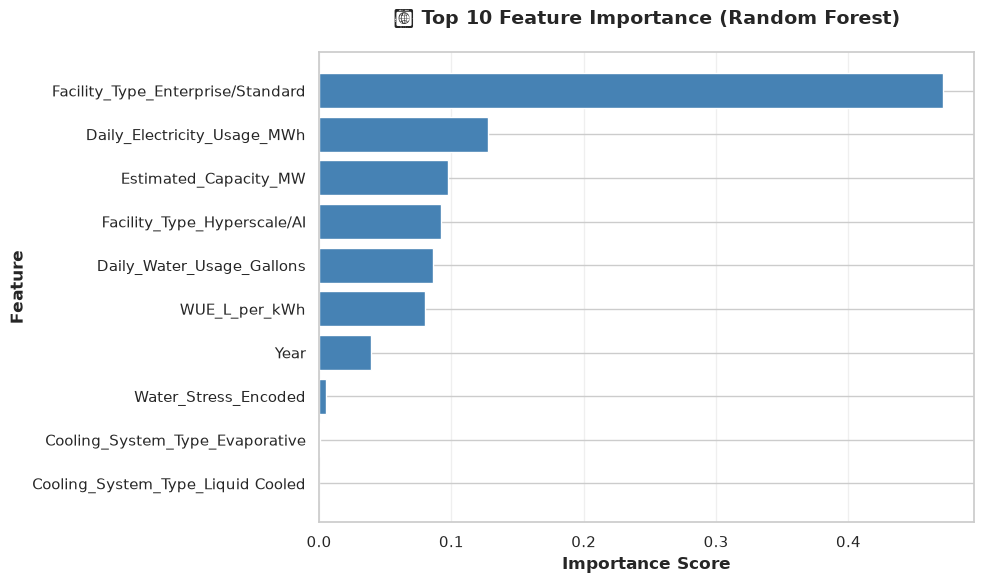


📋 Top 10 Fitur Paling Berpengaruh:


,Feature,Importance
6,Facility_Type_Enterprise/Standard,0.471275
3,Daily_Electricity_Usage_MWh,0.127413
1,Estimated_Capacity_MW,0.097175
7,Facility_Type_Hyperscale/AI,0.092214
4,Daily_Water_Usage_Gallons,0.086223
2,WUE_L_per_kWh,0.080260
0,Year,0.039614
5,Water_Stress_Encoded,0.005300
8,Cooling_System_Type_Evaporative,0.000362
9,Cooling_System_Type_Liquid Cooled,0.000164


In [34]:
# Ambil feature importance dari Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualisasi Top 10 fitur
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('🔝 Top 10 Feature Importance (Random Forest)', fontsize=14, fontweight='bold', pad=20)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n📋 Top 10 Fitur Paling Berpengaruh:')
display(feature_importance.head(10).style.background_gradient(cmap='Blues', subset=['Importance']))

## 🎨 24. Visualisasi: Prediksi vs Aktual

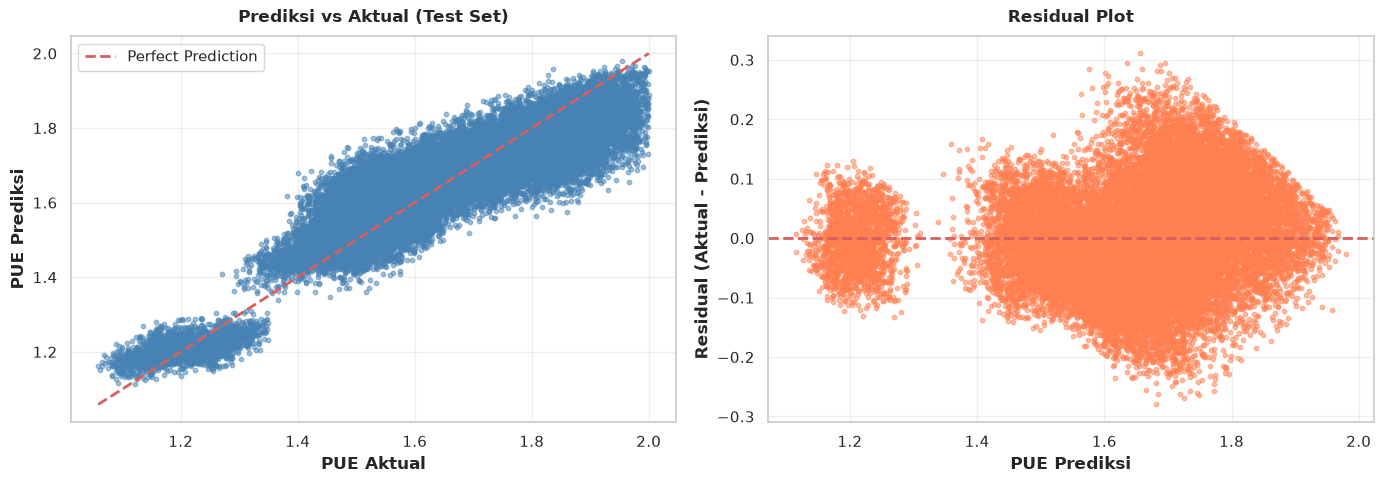


📊 Statistik Error:
   Mean Residual     : 0.0006
   Std Residual      : 0.0840
   Max Absolute Error: 0.3108


In [35]:
# Prediksi dengan model terbaik (Random Forest)
y_pred_test = rf_model.predict(X_test)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_test, alpha=0.5, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('PUE Aktual', fontweight='bold')
axes[0].set_ylabel('PUE Prediksi', fontweight='bold')
axes[0].set_title('Prediksi vs Aktual (Test Set)', fontweight='bold', pad=10)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual plot
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.5, s=10, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('PUE Prediksi', fontweight='bold')
axes[1].set_ylabel('Residual (Aktual - Prediksi)', fontweight='bold')
axes[1].set_title('Residual Plot', fontweight='bold', pad=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📊 Statistik Error:')
print(f'   Mean Residual     : {residuals.mean():.4f}')
print(f'   Std Residual      : {residuals.std():.4f}')
print(f'   Max Absolute Error: {abs(residuals).max():.4f}')

## 📝 25. Kesimpulan Modeling

**Ringkasan Hasil:**

✅ **Model yang Dicoba:**
- Linear Regression (baseline)
- Random Forest Regressor
- Gradient Boosting Regressor

🎯 **Metrik Evaluasi:**
- MAE (Mean Absolute Error): Rata-rata error absolut
- RMSE (Root Mean Squared Error): Lebih sensitif terhadap outlier
- R² Score: Proporsi variance yang dijelaskan model (0-1, semakin tinggi semakin baik)

🏆 **Model Terbaik:** (Lihat hasil di atas)

📌 **Next Steps (Optional):**
- Hyperparameter tuning dengan GridSearchCV/RandomizedSearchCV
- Coba algoritma lain (XGBoost, LightGBM)
- Ensemble methods (stacking, blending)
- Feature engineering lebih lanjut

---
# 💾 MODEL DEPLOYMENT

Simpan model terbaik dan preprocessing objects untuk deployment.

---

## 26. Simpan Model Terbaik & Preprocessing Objects

In [38]:
import joblib
import os
from datetime import datetime

# Buat folder untuk menyimpan model
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Timestamp untuk versioning
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Tentukan model terbaik berdasarkan R² Score
models_dict = {
    'Linear Regression': lr_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

best_model_name = comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']
best_model = models_dict[best_model_name]
best_r2 = comparison_df['Test R²'].max()

print(f'🏆 Model Terbaik: {best_model_name}')
print(f'   Test R² Score: {best_r2:.4f}\n')

# Simpan model
model_filename = f'{MODEL_DIR}/best_model_{timestamp}.joblib'
joblib.dump(best_model, model_filename)
print(f'✅ Model disimpan: {model_filename}')

# Simpan scaler
scaler_filename = f'{MODEL_DIR}/scaler_{timestamp}.joblib'
joblib.dump(scaler, scaler_filename)
print(f'✅ Scaler disimpan: {scaler_filename}')

# Simpan feature names
feature_names = X_train.columns.tolist()
features_filename = f'{MODEL_DIR}/feature_names_{timestamp}.joblib'
joblib.dump(feature_names, features_filename)
print(f'✅ Feature names disimpan: {features_filename}')

# Simpan metadata model
model_metadata = {
    'model_name': best_model_name,
    'timestamp': timestamp,
    'test_r2': best_r2,
    'test_mae': comparison_df.loc[comparison_df['Model'] == best_model_name, 'Test MAE'].values[0],
    'test_rmse': comparison_df.loc[comparison_df['Model'] == best_model_name, 'Test RMSE'].values[0],
    'feature_count': len(feature_names),
    'training_samples': len(X_train)
}

metadata_filename = f'{MODEL_DIR}/model_metadata_{timestamp}.joblib'
joblib.dump(model_metadata, metadata_filename)
print(f'✅ Metadata disimpan: {metadata_filename}')

print(f'\n📦 Semua file disimpan di folder: {MODEL_DIR}/')

🏆 Model Terbaik: Random Forest
   Test R² Score: 0.8057

✅ Model disimpan: models/best_model_20260612_215451.joblib
✅ Scaler disimpan: models/scaler_20260612_215451.joblib
✅ Feature names disimpan: models/feature_names_20260612_215451.joblib
✅ Metadata disimpan: models/model_metadata_20260612_215451.joblib

📦 Semua file disimpan di folder: models/


## 27. Test Load Model (Simulasi Deployment)

In [39]:
# Load model yang sudah disimpan
print('🔄 Loading saved model...\n')

loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
loaded_features = joblib.load(features_filename)
loaded_metadata = joblib.load(metadata_filename)

print('✅ Model berhasil di-load!')
print(f'\n📋 Model Metadata:')
for key, value in loaded_metadata.items():
    print(f'   {key:20s}: {value}')

# Test prediksi dengan model yang di-load
print(f'\n🧪 Testing model dengan 5 sample dari test set...')
test_sample = X_test.head(5)
predictions = loaded_model.predict(test_sample)

result_df = pd.DataFrame({
    'PUE Aktual': y_test.head(5).values,
    'PUE Prediksi': predictions,
    'Error': y_test.head(5).values - predictions
})

print('\n📊 Hasil Prediksi:')
display(result_df.style.format(precision=4)
                       .background_gradient(cmap='RdYlGn_r', subset=['Error']))

print('\n✅ Model siap untuk deployment!')

🔄 Loading saved model...

✅ Model berhasil di-load!

📋 Model Metadata:
   model_name          : Random Forest
   timestamp           : 20260612_215451
   test_r2             : 0.8057112866091427
   test_mae            : 0.06741274573639265
   test_rmse           : 0.08400671808151709
   feature_count       : 10
   training_samples    : 101416

🧪 Testing model dengan 5 sample dari test set...

📊 Hasil Prediksi:


,PUE Aktual,PUE Prediksi,Error
0,1.9060,1.7959,0.1101
1,1.7380,1.7122,0.0258
2,1.7360,1.7799,-0.0439
3,1.7040,1.7313,-0.0273
4,1.5050,1.5520,-0.0470



✅ Model siap untuk deployment!


## 28. Cara Menggunakan Model untuk Prediksi Baru

In [40]:
def predict_pue(new_data, model_path, scaler_path, features_path):
    """
    Function untuk melakukan prediksi PUE dengan model yang sudah disimpan.
    
    Parameters:
    -----------
    new_data : dict or DataFrame
        Data baru untuk prediksi (harus sudah di-encode seperti saat training)
    model_path : str
        Path ke file model (.joblib)
    scaler_path : str
        Path ke file scaler (.joblib)
    features_path : str
        Path ke file feature names (.joblib)
        
    Returns:
    --------
    float : Prediksi nilai PUE
    """
    # Load model dan preprocessing objects
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    feature_names = joblib.load(features_path)
    
    # Convert ke DataFrame jika perlu
    if isinstance(new_data, dict):
        new_data = pd.DataFrame([new_data])
    
    # Pastikan kolom sesuai urutan saat training
    new_data = new_data[feature_names]
    
    # Scale data (hanya kolom numerik yang di-scale saat training)
    # NOTE: Ini simplified version, di production perlu handle encoding juga
    
    # Prediksi
    prediction = model.predict(new_data)[0]
    
    return prediction

print('✅ Function predict_pue() siap digunakan!')
print('\n💡 Contoh penggunaan:')
print('   prediction = predict_pue(new_data, model_path, scaler_path, features_path)')

✅ Function predict_pue() siap digunakan!

💡 Contoh penggunaan:
   prediction = predict_pue(new_data, model_path, scaler_path, features_path)


## 📝 Ringkasan Deployment

✅ **File yang Disimpan:**
1. `best_model_*.joblib` - Model ML terbaik
2. `scaler_*.joblib` - StandardScaler untuk preprocessing
3. `feature_names_*.joblib` - Urutan dan nama fitur
4. `model_metadata_*.joblib` - Informasi performa model

📦 **Lokasi:** Folder `models/`

🔧 **Cara Pakai di Production:**
```python
# Load model
model = joblib.load('models/best_model_XXXXXXXX.joblib')
scaler = joblib.load('models/scaler_XXXXXXXX.joblib')

# Prediksi
prediction = model.predict(new_data_scaled)
```

⚠️ **Penting:**
- Data baru harus melalui preprocessing yang sama (encoding, scaling)
- Urutan fitur harus sama dengan saat training
- Simpan versi library (sklearn, numpy, pandas) untuk reproducibility

---
🎉 **PROJECT SELESAI!**